# Hands and Palm Images Dataset - Exploratory Data Analysis (EDA)

## **Step** 1: Import Libraries

In [1]:
import os
import random
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# **Download the dataset**

In [3]:
import kagglehub

path = kagglehub.dataset_download("shyambhu/hands-and-palm-images-dataset")

print(path)

100%|██████████| 634M/634M [00:30<00:00, 21.5MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/shyambhu/hands-and-palm-images-dataset/versions/2


# Check the files

In [4]:
import os

print(os.listdir(path))

['Hands', 'HandInfo.csv']


# Load the CSV file

In [7]:
import pandas as pd
import os

csv_path = os.path.join(path, "HandInfo.csv")

print(csv_path)

df = pd.read_csv(csv_path)

df.head()

/root/.cache/kagglehub/datasets/shyambhu/hands-and-palm-images-dataset/versions/2/HandInfo.csv


,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0


# Dataset Shape

In [8]:
print("Dataset Shape:", df.shape)

Dataset Shape: (11076, 9)


# Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11076 entries, 0 to 11075
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              11076 non-null  int64 
 1   age             11076 non-null  int64 
 2   gender          11076 non-null  object
 3   skinColor       11076 non-null  object
 4   accessories     11076 non-null  int64 
 5   nailPolish      11076 non-null  int64 
 6   aspectOfHand    11076 non-null  object
 7   imageName       11076 non-null  object
 8   irregularities  11076 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 778.9+ KB


# Missing Values

In [10]:
df.isnull().sum()

,0
id,0
age,0
gender,0
skinColor,0
accessories,0
nailPolish,0
aspectOfHand,0
imageName,0
irregularities,0


# Statistical Summary

In [11]:
df.describe()

,id,age,accessories,nailPolish,irregularities
count,1.107600e+04,11076.000000,11076.000000,11076.000000,11076.000000
mean,2.031043e+05,22.494583,0.289906,0.096334,0.014807
std,1.086731e+06,6.918974,0.453739,0.295063,0.120784
min,0.000000e+00,18.000000,0.000000,0.000000,0.000000
25%,5.760000e+02,21.000000,0.000000,0.000000,0.000000
50%,1.050000e+03,21.000000,0.000000,0.000000,0.000000
75%,1.539250e+03,22.000000,1.000000,0.000000,0.000000
max,9.000000e+06,75.000000,1.000000,1.000000,1.000000


# Dataset Columns

In [12]:
df.columns

Index(['id', 'age', 'gender', 'skinColor', 'accessories', 'nailPolish',
       'aspectOfHand', 'imageName', 'irregularities'],
      dtype='object')

# Load the image folder

In [5]:
image_folder = os.path.join(path, "Hands", "Hands")

print(image_folder)

/root/.cache/kagglehub/datasets/shyambhu/hands-and-palm-images-dataset/versions/2/Hands/Hands


# Display Sample Image

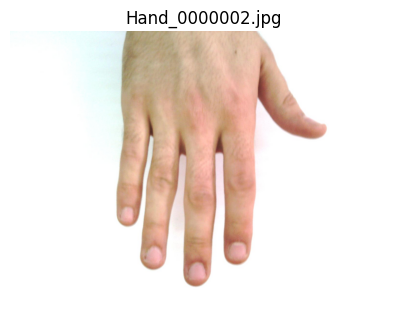

In [13]:
image_name = df.loc[0, "imageName"]

img = Image.open(os.path.join(image_folder, image_name))

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title(image_name)
plt.show()

# Hand Type Distribution

aspectOfHand
dorsal right    2892
palmar right    2813
dorsal left     2788
palmar left     2583
Name: count, dtype: int64


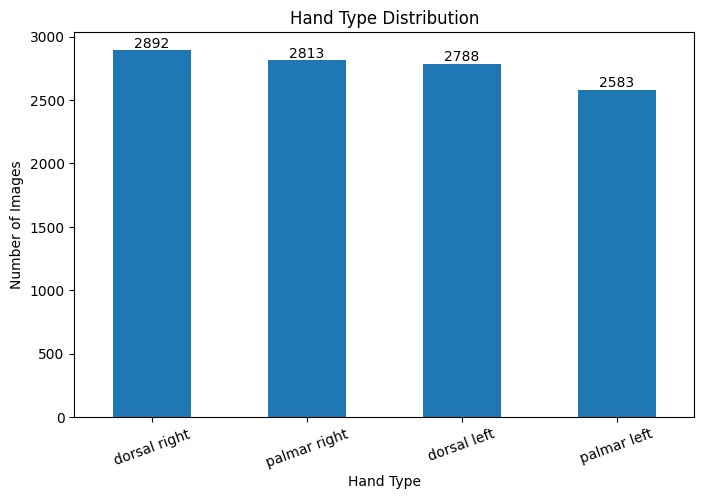

In [14]:
hand_counts = df["aspectOfHand"].value_counts()

print(hand_counts)

plt.figure(figsize=(8,5))
hand_counts.plot(kind="bar")

plt.title("Hand Type Distribution")
plt.xlabel("Hand Type")
plt.ylabel("Number of Images")

plt.xticks(rotation=20)

for i, value in enumerate(hand_counts):
    plt.text(i, value+20, str(value), ha='center')

plt.show()

# Gender Distribution

gender
female    7109
male      3967
Name: count, dtype: int64


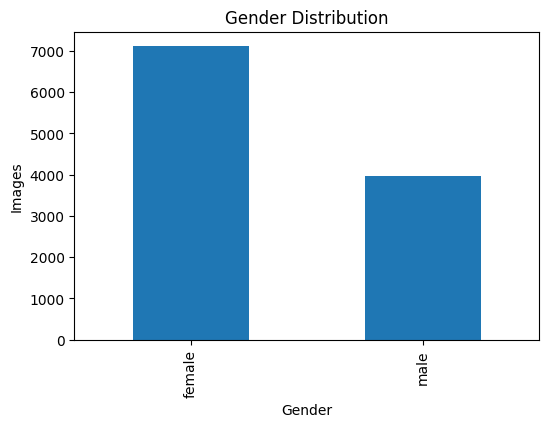

In [15]:
gender = df["gender"].value_counts()

print(gender)

plt.figure(figsize=(6,4))
gender.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Images")

plt.show()

# Age Distribution

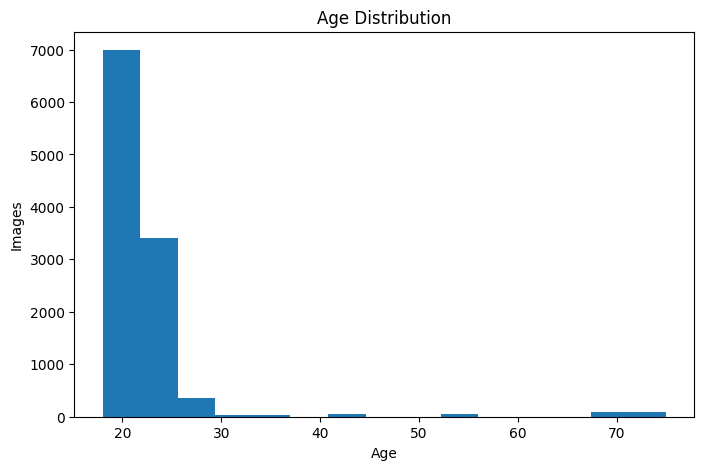

In [16]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Images")

plt.show()

# Skin Color Distribution

skinColor
medium       6495
fair         3493
dark          758
very fair     330
Name: count, dtype: int64


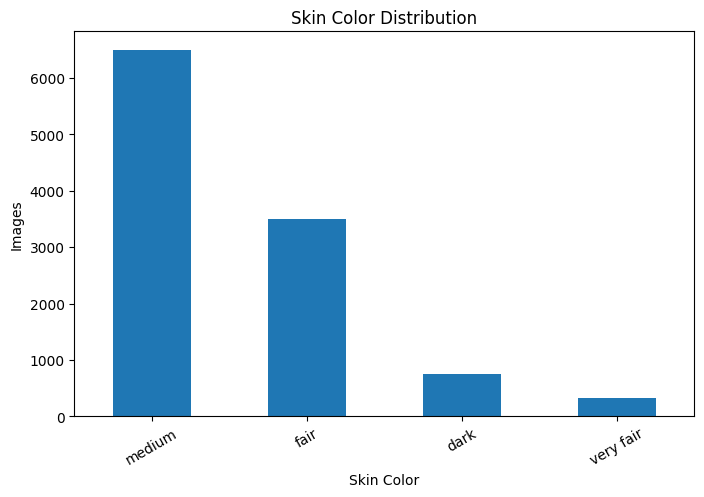

In [17]:
skin = df["skinColor"].value_counts()

print(skin)

plt.figure(figsize=(8,5))
skin.plot(kind="bar")

plt.title("Skin Color Distribution")
plt.xlabel("Skin Color")
plt.ylabel("Images")

plt.xticks(rotation=30)

plt.show()

# Accessories Distribution

accessories
0    7865
1    3211
Name: count, dtype: int64


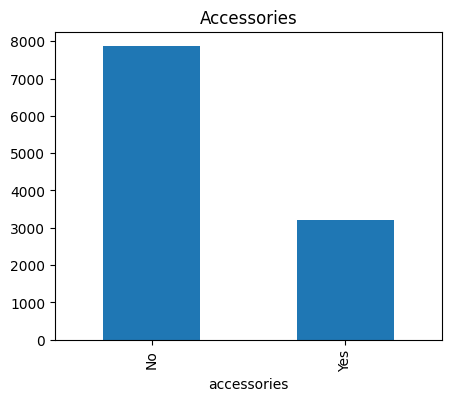

In [18]:
accessories = df["accessories"].value_counts()

print(accessories)

plt.figure(figsize=(5,4))

accessories.plot(kind="bar")

plt.xticks([0,1],["No","Yes"])

plt.title("Accessories")

plt.show()

# Duplicate Image Analysis

In [19]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

if duplicates == 0:
    print("No duplicate records found.")
else:
    print("Dataset contains duplicate records.")

Duplicate Records: 0
No duplicate records found.


# Unique Values in Every Column

In [20]:
print("Unique Values in Each Column\n")

for column in df.columns:
    print(f"{column} : {df[column].nunique()} unique values")

Unique Values in Each Column

id : 189 unique values
age : 18 unique values
gender : 2 unique values
skinColor : 4 unique values
accessories : 2 unique values
nailPolish : 2 unique values
aspectOfHand : 4 unique values
imageName : 11076 unique values
irregularities : 2 unique values


# Memory Usage Analysis

In [22]:
print(df.memory_usage(deep=True))

print("\nTotal Memory Usage:")

print(round(df.memory_usage(deep=True).sum() / 1024, 2), "KB")

Index                132
id                 88608
age                88608
gender            601246
skinColor         601668
accessories        88608
nailPolish         88608
aspectOfHand      670265
imageName         719940
irregularities     88608
dtype: int64

Total Memory Usage:
2965.13 KB


# Image Brightness Analysis

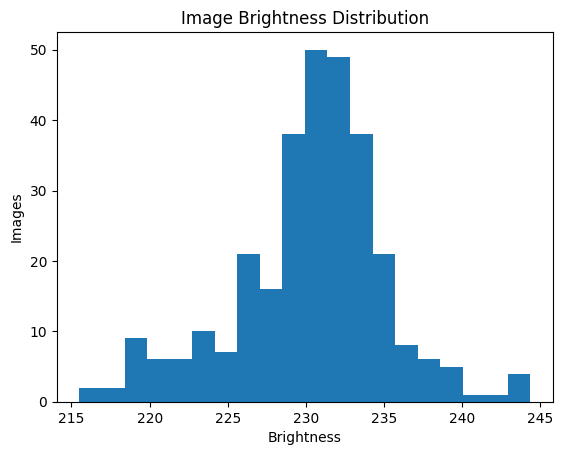

In [23]:
from PIL import Image
import numpy as np

brightness=[]

for img_name in df["imageName"][:300]:

    img=Image.open(os.path.join(image_folder,img_name))

    gray=img.convert("L")

    brightness.append(np.array(gray).mean())

plt.hist(brightness,bins=20)

plt.title("Image Brightness Distribution")

plt.xlabel("Brightness")

plt.ylabel("Images")

plt.show()

# Nail Polish by Hand Type

nailPolish       0    1
aspectOfHand           
dorsal left   2255  533
dorsal right  2358  534
palmar left   2583    0
palmar right  2813    0


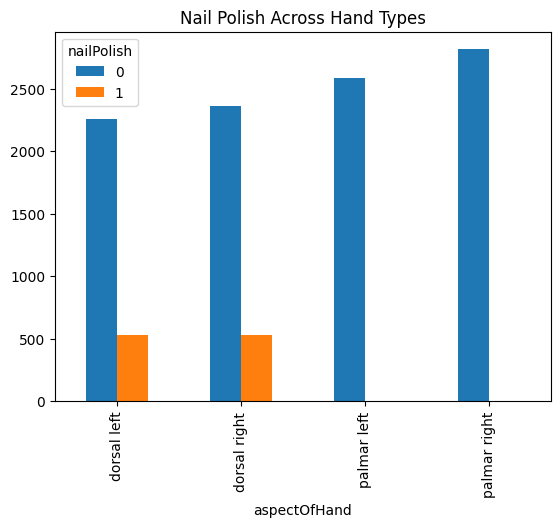

In [24]:
nail = pd.crosstab(df["aspectOfHand"], df["nailPolish"])

print(nail)

nail.plot(kind="bar")

plt.title("Nail Polish Across Hand Types")

plt.show()

# Display Only Left Palm Images

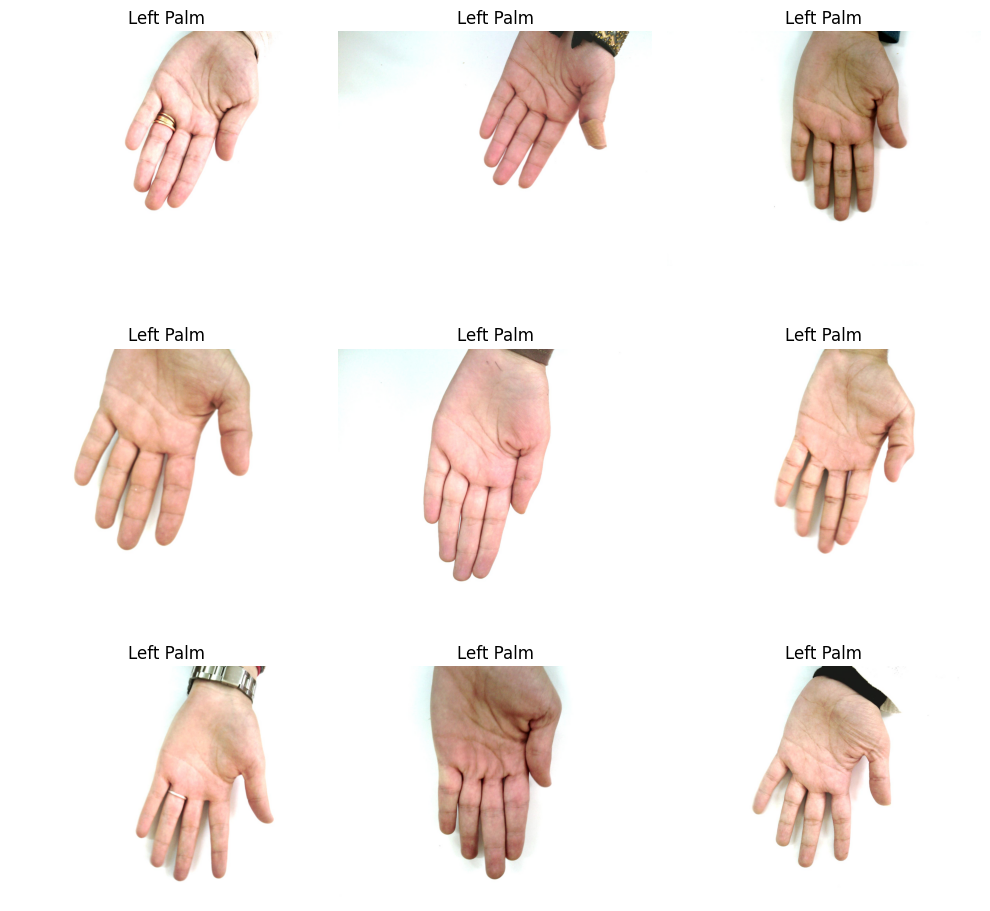

In [26]:
left_palm = df[df["aspectOfHand"]=="palmar left"]

sample = left_palm.sample(9, random_state=42)

plt.figure(figsize=(10,10))

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(os.path.join(image_folder, row["imageName"]))

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title("Left Palm")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Palmar Images Only

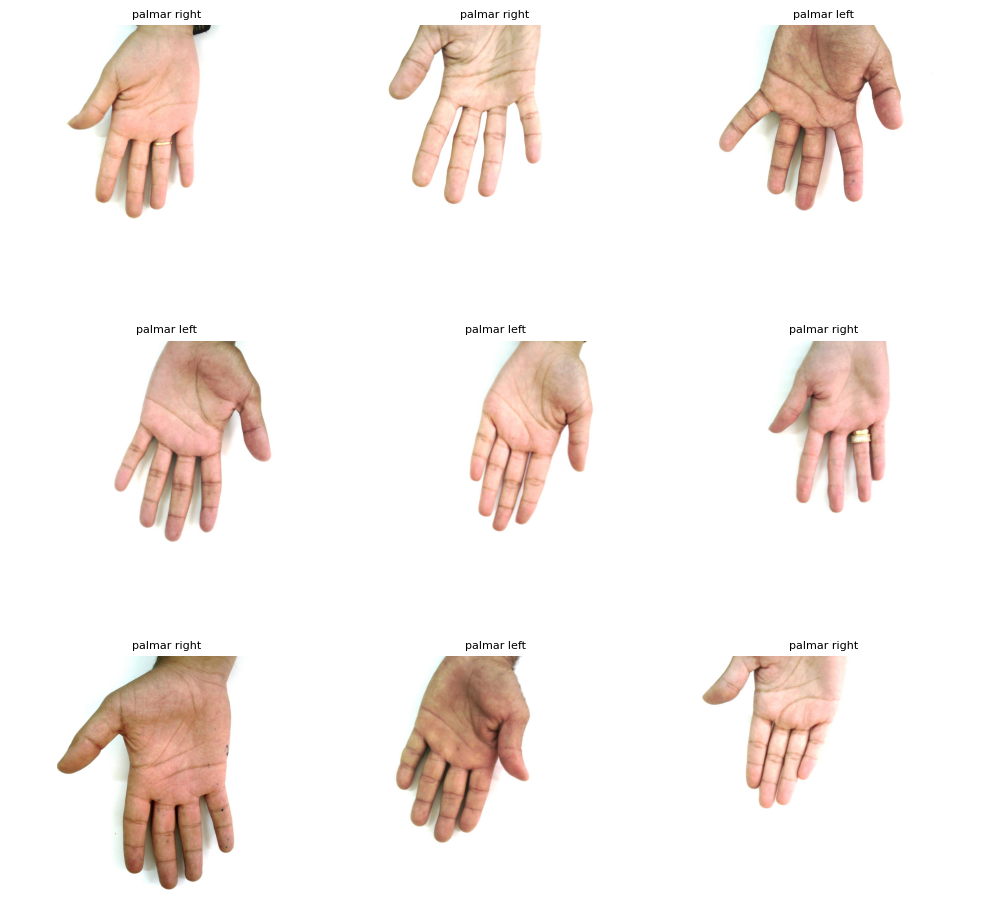

In [34]:
palmar = df[df["aspectOfHand"].str.contains("palmar")]

sample = palmar.sample(9, random_state=42)

plt.figure(figsize=(10,10))

for i, (_, row) in enumerate(sample.iterrows()):

    img = Image.open(os.path.join(image_folder, row["imageName"]))

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(row["aspectOfHand"], fontsize=8)

    plt.axis("off")

plt.tight_layout()

plt.show()

# Correlation Heatmap

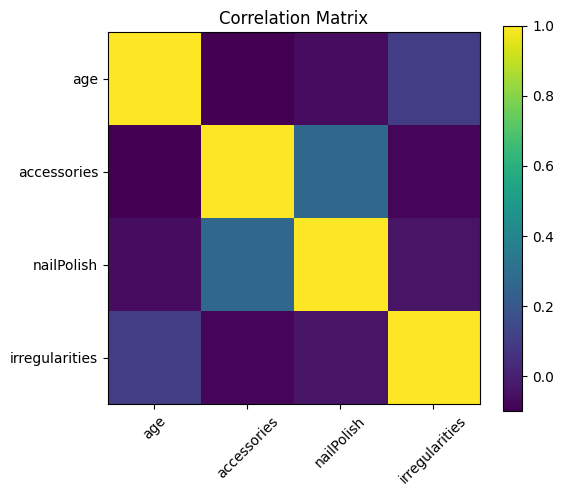

                     age  accessories  nailPolish  irregularities
age             1.000000    -0.098741   -0.062350        0.099821
accessories    -0.098741     1.000000    0.266177       -0.078332
nailPolish     -0.062350     0.266177    1.000000       -0.040027
irregularities  0.099821    -0.078332   -0.040027        1.000000


In [35]:
import matplotlib.pyplot as plt

corr = df[["age","accessories","nailPolish","irregularities"]].corr()

plt.figure(figsize=(6,5))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

print(corr)

# Final EDA Conclusion

In [37]:
from PIL import Image
import os

sizes = []

for image_name in df["imageName"]:
    image_path = os.path.join(image_folder, image_name)

    img = Image.open(image_path)

    sizes.append(img.size)

print("Unique Image Sizes:")
print(set(sizes))

Unique Image Sizes:
{(1600, 1200)}


In [38]:
print("="*60)
print("EDA SUMMARY")
print("="*60)

print(f"Total Images        : {len(df)}")
print(f"Total Features      : {len(df.columns)}")
print(f"Missing Values      : {df.isnull().sum().sum()}")
print(f"Image Resolution    : {sizes[0]}")
print(f"Hand Types          : {df['aspectOfHand'].unique()}")
print(f"Gender Categories   : {df['gender'].unique()}")
print(f"Skin Colors         : {df['skinColor'].unique()}")

print("\nProject Recommendation")
print("- Use only Palmar Left and Palmar Right images.")
print("- Remove dorsal images during preprocessing.")
print("- Resize images before CNN training.")
print("- Normalize pixel values.")
print("- Apply data augmentation if required.")

EDA SUMMARY
Total Images        : 11076
Total Features      : 9
Missing Values      : 0
Image Resolution    : (1600, 1200)
Hand Types          : ['dorsal right' 'dorsal left' 'palmar left' 'palmar right']
Gender Categories   : ['male' 'female']
Skin Colors         : ['fair' 'dark' 'medium' 'very fair']

Project Recommendation
- Use only Palmar Left and Palmar Right images.
- Remove dorsal images during preprocessing.
- Resize images before CNN training.
- Normalize pixel values.
- Apply data augmentation if required.


# Final EDA Summary – Hands and Palm Images Dataset
# Dataset Overview
Dataset Summary
All images have a uniform resolution of 1600 × 1200 pixels.

*   The dataset contains 11,076 hand images with 9 attributes.

*   No missing values were found in any column.

*   All images have a uniform resolution of 1600 × 1200 pixels.




# Project-Specific Findings

*   Only Palmar Left and Palmar Right images are used because they clearly show the palm lines required for palmistry analysis.
*   Dorsal Left and Dorsal Right images are excluded since they do not contain visible palm lines.

*   The aspectOfHand column is used to filter the required palm images during preprocessing.

*   The dataset is suitable for MediaPipe hand landmark detection, image preprocessing, and CNN-based model training.
*    Overall, the dataset provides a strong foundation for developing the Palmistry & Tarot Intelligence Platform.
